# Makemore: Wavenet

https://www.youtube.com/watch?v=t3YJ5hKiMQ0&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&index=6

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [3]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [80]:
# build the dataset
block_size = 8  # context length: how many characters do we take to predict the next one?


def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y


import random

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])  # 80%
Xdev, Ydev = build_dataset(words[n1:n2])  # 10%
Xte, Yte = build_dataset(words[n2:])  # 10%

torch.Size([182424, 8]) torch.Size([182424])
torch.Size([22836, 8]) torch.Size([22836])
torch.Size([22886, 8]) torch.Size([22886])


In [81]:
for x, y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> n
.......n --> y
......ny --> r
.....nyr --> e
....nyre --> e
...nyree --> .
........ --> e
.......e --> d
......ed --> i
.....edi --> e
....edie --> .
........ --> c
.......c --> o
......co --> a
.....coa --> l
....coal --> s
...coals --> o
..coalso --> n
.coalson --> .
........ --> s


In [131]:
class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # kaiming init
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0,1)

            xmean = x.mean(dim, keepdim=True) # batch mean
            xvar = x.var(dim, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean)/torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # update the buffers

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean # exponential moving average
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]

class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out

    def parameters(self):
        return []


class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [132]:
torch.manual_seed(42); # Reproducibility

In [150]:
n_embd = 24 # dimensionality of character embedding vectors
n_hidden = 128 # number of neurons the hidden layer of the MLP

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

76579


In [151]:
ix = torch.randint(0, Xtr.shape[0], (4,)) # batch of 4 examples
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0, 20, 25, 17, 21],
        [ 0,  0,  0, 13,  5, 25,  5, 18],
        [ 0,  0, 23,  9, 14,  9,  6, 18],
        [ 0,  0,  0,  0,  1, 13, 15, 14]])

In [152]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 24)
FlattenConsecutive : (4, 4, 48)
Linear : (4, 4, 128)
BatchNorm1d : (4, 4, 128)
Tanh : (4, 4, 128)
FlattenConsecutive : (4, 2, 256)
Linear : (4, 2, 128)
BatchNorm1d : (4, 2, 128)
Tanh : (4, 2, 128)
FlattenConsecutive : (4, 256)
Linear : (4, 128)
BatchNorm1d : (4, 128)
Tanh : (4, 128)
Linear : (4, 27)


In [153]:
model.layers[0].out.shape # output of Embedding layer

torch.Size([4, 8, 24])

In [154]:
model.layers[1].out.shape # output of Flatten layer

torch.Size([4, 4, 48])

In [155]:
model.layers[2].out.shape #output of Linear Layer

torch.Size([4, 4, 128])

In [156]:
(torch.randn(4, 4, 20) @ torch.randn(20, 200) + torch.randn(200)).shape

# (1 2) (3 4) (5 6) (7 8)
# 4 groups of 2 chars each with 10 dim embedding

torch.Size([4, 4, 200])

In [157]:
logits.shape

torch.Size([4, 27])

Batchnorm is working over in parallel in 4 * 68 instead of just 68 channels. so we are standardizing over each of the pairs instead of all 4 of them.

In [158]:
e = torch.randn(32, 4, 68)
emean = e.mean(0, keepdim = True) # 1, 4, 68, mean for only first dim
evar = e.var(0, keepdim= True) # 1, 4, 68
ehat = (e-emean)/torch.sqrt(evar+1e-5)
ehat.shape


torch.Size([32, 4, 68])

In [159]:
e = torch.randn(32, 4, 68)
emean = e.mean((0,1), keepdim = True) # 1, 4, 68, mean for only first dim
evar = e.var((0,1), keepdim= True) # 1, 4, 68
ehat = (e-emean)/torch.sqrt(evar+1e-5)
ehat.shape

torch.Size([32, 4, 68])

In [160]:
emean.shape

torch.Size([1, 1, 68])

In [161]:
model.layers[3].running_mean.shape

torch.Size([1, 1, 128])

In [162]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb) # loss function

    # backword pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update: simple SGD
    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.2727
  10000/ 200000: 2.2061
  20000/ 200000: 2.4393
  30000/ 200000: 1.9738
  40000/ 200000: 2.1990
  50000/ 200000: 2.3825
  60000/ 200000: 1.8748
  70000/ 200000: 1.8915
  80000/ 200000: 2.0328
  90000/ 200000: 1.7457
 100000/ 200000: 1.7106
 110000/ 200000: 1.6198
 120000/ 200000: 2.1189
 130000/ 200000: 2.0403
 140000/ 200000: 1.8577
 150000/ 200000: 2.1273
 160000/ 200000: 1.5130
 170000/ 200000: 1.8780
 180000/ 200000: 1.7147
 190000/ 200000: 1.5872


`lossi` is a python list of floats. Plotting it directly with `plt.plot(lossi)` looks very messy because we are doing the backward pass with batches, which can lead to higher variances on the loss. This doesn't give us a very clear view of the loss graph.

One way to do this is average out every 1000 blocks of losses, giving us a better looking graph.

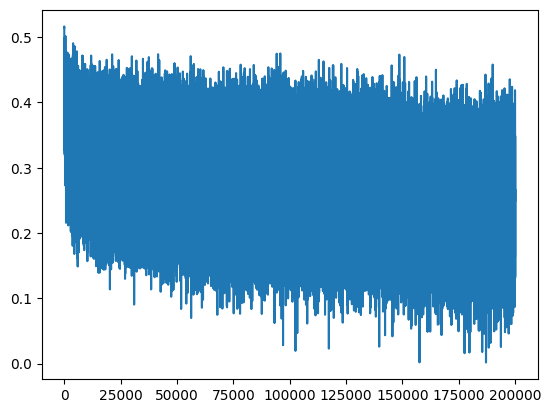

In [163]:
plt.plot(lossi)

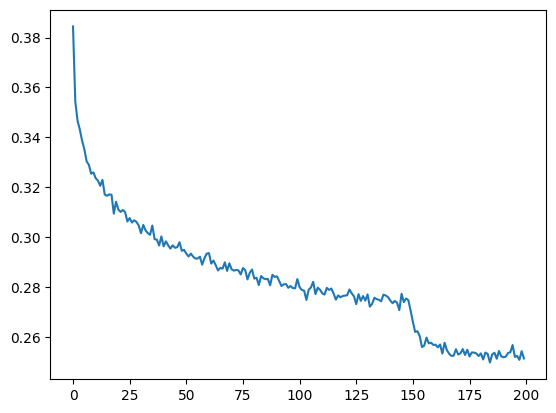

In [164]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [165]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
    layer.training = False

In [166]:
# evaluate the loss
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7649977207183838
val 1.988662838935852


Performance Log
- original (3 char context + 200 hidden neurons, 12K params): train 2.057, val 2.107
- context: 3 -> 8 (22K params): train 1.918, val: 2.027
- wavenet: train: 1.765, val: 1.989

In [167]:
 # sample from the model
for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        logits = model(torch.tensor([context]))

        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

jacquelynn.
avianna.
azure.
bren.
thora.
huazly.
ariss.
blighteme.
armani.
everecc.
kettel.
nadee.
moniel.
elanee.
crawdon.
belkem.
tazuri.
rayner.
audrey.
nethel.
